In [1]:
%reload_ext autoreload
%autoreload 2

In [8]:
import sys
import argparse
import datetime
import math
import os
import random
import time
from typing import Dict, Union

import torch
from datasets import (
    Dataset,
    DatasetDict,
    concatenate_datasets,
    get_dataset_config_names,
    load_dataset,
    load_from_disk
)

from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer, SentenceTransformerTrainer
from sentence_transformers.evaluation import (
    InformationRetrievalEvaluator,
    SequentialEvaluator,
    TripletEvaluator,
)
from sentence_transformers.losses import MultipleNegativesRankingLoss
from sentence_transformers.training_args import (
    BatchSamplers,
    MultiDatasetBatchSamplers,
    SentenceTransformerTrainingArguments,
)
from torch.nn.parallel import DistributedDataParallel
from torch.optim.lr_scheduler import LambdaLR
from transformers.optimization import get_scheduler  # For fallback in custom trainer


sys.path.append("../model_exploration")
from utils import (
    PreTokenizedCollator,
    build_dataset_configs,
    get_gpu_info,
    load_and_cache_datasets,
    prepare_evaluators,
)

In [22]:
N_DATA_SRC = None
NROWS = 100
configs = build_dataset_configs(N_DATA_SRC)

ds_dict = load_and_cache_datasets(configs, CACHE_DIR= f"../data/stage1_cache/NROWS_{NROWS}", NROWS=NROWS, rank=0)



RANK:0;▶ Processing: squad_v2
RANK:0;▶ Processing: wikipedia
RANK:0;▶ Processing: StackExchange_Math_titlebody_answer
RANK:0;▶ Processing: StackExchange_Math_title_answer
RANK:0;▶ Processing: StackExchange_title_body
RANK:0;▶ Processing: StackExchange_Duplicates_titlebody_titlebody
RANK:0;▶ Processing: StackExchange_Duplicates_body_body
RANK:0;▶ Processing: StackExchange_Duplicates_title_title
RANK:0;▶ Processing: Natural_Questions
RANK:0;▶ Processing: PAQ
RANK:0;▶ Processing: Gooaq
RANK:0;▶ Processing: yahoo_title_answers
RANK:0;▶ Processing: msmacro_triplet
RANK:0;▶ Processing: trivia_qa_triplet
RANK:0;▶ Processing: nli_for_simcse_triplet
RANK:0;▶ Processing: quora_dup_triplet
RANK:0;▶ Processing: WikiAnswers
RANK:0;▶ Processing: eli5
RANK:0;▶ Processing: sentence_compression
RANK:0;▶ Processing: Flickr30k_Captions
RANK:0;▶ Processing: Coco_Captions
RANK:0;▶ Processing: xsum
RANK:0;▶ Processing: agnews
RANK:0;▶ Processing: npr
RANK:0;▶ Processing: cnn_dailymail
RANK:0;▶ Processing: c

In [23]:
dxs = []
for dname, ds_d in ds_dict.items():
    # concatenate the different splits
    ds_d = concatenate_datasets([ds_d[split] for split in ds_d.keys() ])
    dxs.append(ds_d)

all_dx = concatenate_datasets(dxs)

all_dx

Dataset({
    features: ['anchor', 'positive', 'negative'],
    num_rows: 37400
})

In [30]:
df = all_dx.to_pandas()

model = SentenceTransformer('nasa-impact/indus-sde-st-v0.1')
tokenizer = model.tokenizer


In [31]:
df.head()

,anchor,positive,negative
0,What did Beyoncé's mother own when Beyoncé was...,"Beyoncé Giselle Knowles was born in Houston, T...",None
1,What role did Beyoncé have in Destiny's Child?,Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ b...,None
2,Beyonce's group changed their name to Destiny'...,The group changed their name to Destiny's Chil...,None
3,What choir did Beyoncé sing in for two years?,Beyoncé attended St. Mary's Elementary School ...,None
4,Which song did Beyonce sing to win a competiti...,Beyoncé attended St. Mary's Elementary School ...,None


In [32]:
# --- Step 1: Tokenize 'anchor' and 'positive' columns ---
# Use tokenizer.encode to convert text into token IDs.
# add_special_tokens=True ensures that special tokens (like [CLS] and [SEP]) are included
# in the token count, which is standard for most transformer models.
df['anchor_tokens_ids'] = df['anchor'].apply(lambda x: tokenizer.encode(x, add_special_tokens=True))
df['positive_tokens_ids'] = df['positive'].apply(lambda x: tokenizer.encode(x, add_special_tokens=True))

print("Tokenization complete.")

# --- Step 2: Calculate the number of tokens for each column ---
# The number of tokens is simply the length of the list of token IDs.
df['num_anchor_tokens'] = df['anchor_tokens_ids'].apply(len)
df['num_positive_tokens'] = df['positive_tokens_ids'].apply(len)

# --- Step 3: Calculate the total token count ---
# Sum the number of tokens from 'anchor' and 'positive' columns.
df['total_tokens'] = df['num_anchor_tokens'] + df['num_positive_tokens']


Token indices sequence length is longer than the specified maximum sequence length for this model (1091 > 1024). Running this sequence through the model will result in indexing errors


Tokenization complete.


In [38]:

# The .describe() method provides count, mean, std, min, 25%, 50%, 75%, and max.
print("\n--- 5-Point Summary for Number of Anchor Tokens ---")
print(df['num_anchor_tokens'].describe())



--- 5-Point Summary for Number of Anchor Tokens ---
count    37400.000000
mean       106.409278
std        164.830719
min          3.000000
25%         14.000000
50%         27.000000
75%        139.000000
max       2781.000000
Name: num_anchor_tokens, dtype: float64


In [37]:
print("\n--- 5-Point Summary for Number of Positive Tokens ---")
print(df['num_positive_tokens'].describe())

print("\n--- 5-Point Summary for Total Token Count (Anchor + Positive) ---")
print(df['total_tokens'].describe())


--- 5-Point Summary for Number of Positive Tokens ---
count    37400.000000
mean       301.251791
std        596.764634
min          6.000000
25%         94.000000
50%        180.000000
75%        343.000000
max      28221.000000
Name: num_positive_tokens, dtype: float64

--- 5-Point Summary for Total Token Count (Anchor + Positive) ---
count    37400.000000
mean       407.661070
std        626.286601
min         15.000000
25%        152.000000
50%        276.000000
75%        489.000000
max      28225.000000
Name: total_tokens, dtype: float64


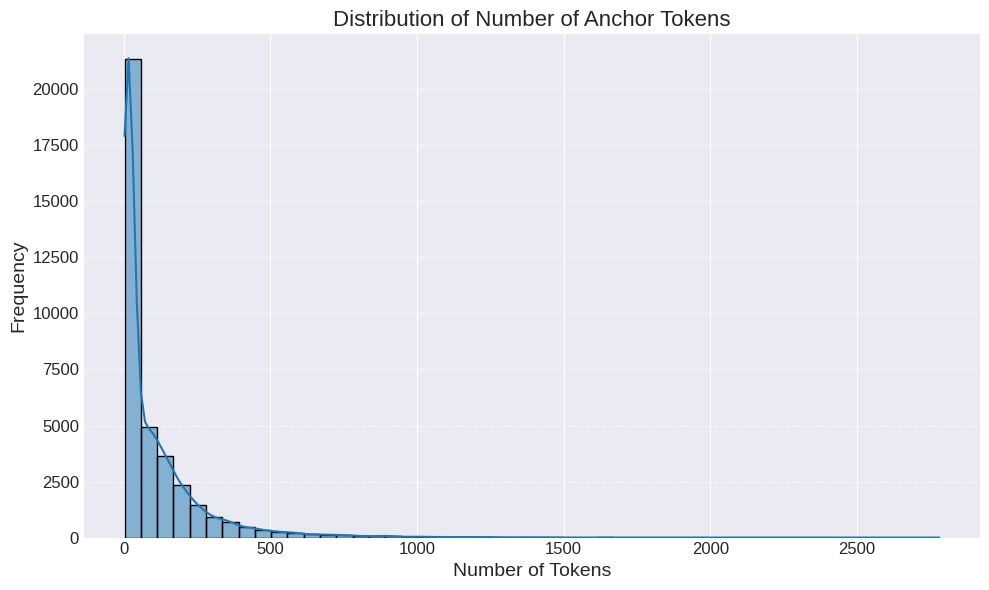

Distribution plot for Anchor Tokens generated.


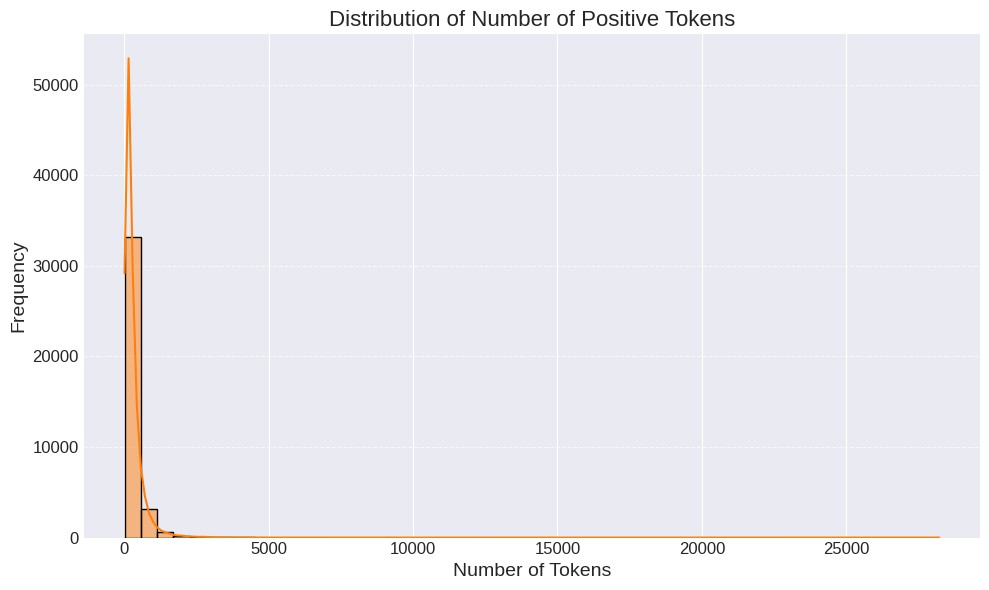

Distribution plot for Positive Tokens generated.


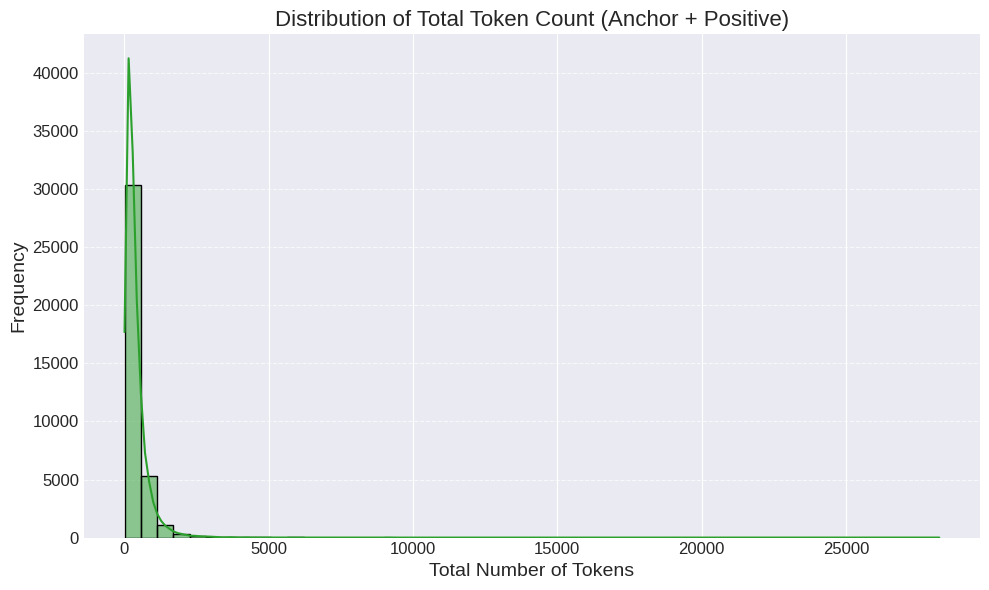

Distribution plot for Total Tokens generated.

Analysis complete.


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid') # Apply a nice style to the plots

# Plot for Number of Anchor Tokens
plt.figure(figsize=(10, 6))
sns.histplot(df['num_anchor_tokens'], bins=50, kde=True, color='#1f77b4', edgecolor='black')
plt.title('Distribution of Number of Anchor Tokens', fontsize=16)
plt.xlabel('Number of Tokens', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("Distribution plot for Anchor Tokens generated.")

# Plot for Number of Positive Tokens
plt.figure(figsize=(10, 6))
sns.histplot(df['num_positive_tokens'], bins=50, kde=True, color='#ff7f0e', edgecolor='black')
plt.title('Distribution of Number of Positive Tokens', fontsize=16)
plt.xlabel('Number of Tokens', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("Distribution plot for Positive Tokens generated.")

# Plot for Total Token Count
plt.figure(figsize=(10, 6))
sns.histplot(df['total_tokens'], bins=50, kde=True, color='#2ca02c', edgecolor='black')
plt.title('Distribution of Total Token Count (Anchor + Positive)', fontsize=16)
plt.xlabel('Total Number of Tokens', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("Distribution plot for Total Tokens generated.")

print("\nAnalysis complete.")

In [39]:
import pandas as pd

data_path = "/rhome/sawale/indus_traning/sentense_transformers/gen_data_stage3/filtered_sde_data/"

df_sde = pd.read_parquet(data_path)

df_sde

,id,url1,title,text,n_words,url2,predicted,prob_included
0,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/data/,ACTIVATE: Data – NASA Langley Research Center...,ACTIVATE: Data - NASA Langley Research Center ...,3975,b'/ACTIVATE/data/',1,0.989475
1,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/,ACTIVATE: Home – NASA Langley Research Center ...,ACTIVATE: Home - NASA Langley Research Center ...,4659,b'/ACTIVATE/',1,0.990293
2,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/media/,ACTIVATE: Media – NASA Langley Research Cente...,ACTIVATE: Media - NASA Langley Research Center...,4458,b'/ACTIVATE/media/',1,0.985873
3,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/instrum...,ACTIVATE: Instruments – NASA Langley Research ...,ACTIVATE: Instruments - NASA Langley Research ...,4126,b'/ACTIVATE/instruments/',1,0.991540
4,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/education/,ACTIVATE: Education – NASA Langley Research C...,ACTIVATE: Education - NASA Langley Research Ce...,4192,b'/ACTIVATE/education/',1,0.992481
...,...,...,...,...,...,...,...,...
331078,/SDE/stsci_space_telescope_science_institute/|...,https://www.stsci.edu/stsci-research/fellowshi...,Host Institutions and the NHFP Employment Poli...,Host Institutions and the NHFP Employment Poli...,1495,b'/stsci-research/fellowships/nasa-hubble-fell...,1,0.997603
331079,/SDE/stsci_space_telescope_science_institute/|...,https://www.stsci.edu/stsci-research/fellowshi...,Frequently Asked Questions | STScI,Frequently Asked Questions | STScI\nSkip to ma...,1669,b'/stsci-research/fellowships/nasa-hubble-fell...,1,0.996331
331080,/SDE/stsci_space_telescope_science_institute/|...,https://www.stsci.edu/stsci-research/fellowshi...,Resources for Current Fellows | STScI,Resources for Current Fellows | STScI\nSkip to...,1117,b'/stsci-research/fellowships/nasa-hubble-fell...,1,0.998509
331081,/SDE/stsci_space_telescope_science_institute/|...,https://www.stsci.edu/stsci-research/fellowshi...,Visa and Benefits Information | STScI,Visa and Benefits Information | STScI\nSkip to...,2001,b'/stsci-research/fellowships/nasa-hubble-fell...,1,0.996940


In [41]:
df_sde['tokens_ids'] = df_sde['text'].apply(lambda x: tokenizer.encode(x, add_special_tokens=True))
print("Tokenization complete.")
df_sde['num_tokens'] = df_sde['tokens_ids'].apply(len)
print("\n--- 5-Point Summary for Token Count for filtered 500k SDE Data ---")
print(df_sde['num_tokens'].describe())

Tokenization complete.

--- 5-Point Summary for Token Count for filtered 500k SDE Data ---
count    331083.000000
mean       1273.076368
std        7173.419881
min         113.000000
25%         281.000000
50%         481.000000
75%         849.000000
max      556853.000000
Name: num_tokens, dtype: float64


In [ ]:
df_sde['num_tokens'].percentile(0.9)

AttributeError: 'Series' object has no attribute 'percentile'